In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
PROJECT_ROOT = Path("../../").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "biomarkers" / "mi_complications"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "eda" / "mi_complications"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Data directory:", DATA_DIR)
print("Exists:", DATA_DIR.exists())
print("Artifact directory:", ARTIFACT_DIR)

Data directory: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\raw\biomarkers\mi_complications
Exists: True
Artifact directory: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\eda\mi_complications


In [18]:
csv_files = list(DATA_DIR.glob("*.csv"))

print("CSV files found:", len(csv_files))

for path in csv_files:
    print(path.name)

CSV files found: 1
Myocardial infarction complications Database.csv


In [19]:
if not csv_files:
    raise FileNotFoundError(f"No CSV file found in {DATA_DIR}")

DATA_PATH = csv_files[0]

df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH.name)
print("Shape:", df.shape)

Loaded: Myocardial infarction complications Database.csv
Shape: (1700, 124)


In [20]:
print("Columns:")
for i, col in enumerate(df.columns, start=1):
    print(i, col)

print("\nFirst 5 rows:")
display(df.head())

Columns:
1 ID
2 AGE
3 SEX
4 INF_ANAM
5 STENOK_AN
6 FK_STENOK
7 IBS_POST
8 IBS_NASL
9 GB
10 SIM_GIPERT
11 DLIT_AG
12 ZSN_A
13 nr_11
14 nr_01
15 nr_02
16 nr_03
17 nr_04
18 nr_07
19 nr_08
20 np_01
21 np_04
22 np_05
23 np_07
24 np_08
25 np_09
26 np_10
27 endocr_01
28 endocr_02
29 endocr_03
30 zab_leg_01
31 zab_leg_02
32 zab_leg_03
33 zab_leg_04
34 zab_leg_06
35 S_AD_KBRIG
36 D_AD_KBRIG
37 S_AD_ORIT
38 D_AD_ORIT
39 O_L_POST
40 K_SH_POST
41 MP_TP_POST
42 SVT_POST
43 GT_POST
44 FIB_G_POST
45 ant_im
46 lat_im
47 inf_im
48 post_im
49 IM_PG_P
50 ritm_ecg_p_01
51 ritm_ecg_p_02
52 ritm_ecg_p_04
53 ritm_ecg_p_06
54 ritm_ecg_p_07
55 ritm_ecg_p_08
56 n_r_ecg_p_01
57 n_r_ecg_p_02
58 n_r_ecg_p_03
59 n_r_ecg_p_04
60 n_r_ecg_p_05
61 n_r_ecg_p_06
62 n_r_ecg_p_08
63 n_r_ecg_p_09
64 n_r_ecg_p_10
65 n_p_ecg_p_01
66 n_p_ecg_p_03
67 n_p_ecg_p_04
68 n_p_ecg_p_05
69 n_p_ecg_p_06
70 n_p_ecg_p_07
71 n_p_ecg_p_08
72 n_p_ecg_p_09
73 n_p_ecg_p_10
74 n_p_ecg_p_11
75 n_p_ecg_p_12
76 fibr_ter_01
77 fibr_ter_02
78 fibr_t

,ID,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,...,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN,LET_IS
0,1,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,2,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,3,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,4,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,0.0,...,0,0,0,0,0,0,1,0,0,0
4,5,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing = missing.sort_values(
    "missing_percent",
    ascending=False
)

display(missing.head(30))

,missing_count,missing_percent
KFK_BLOOD,1696,99.764706
IBS_NASL,1628,95.764706
D_AD_KBRIG,1076,63.294118
S_AD_KBRIG,1076,63.294118
NOT_NA_KB,686,40.352941
LID_KB,677,39.823529
NA_KB,657,38.647059
NA_BLOOD,375,22.058824
GIPER_NA,375,22.058824
K_BLOOD,371,21.823529


In [22]:
high_missing = missing[missing["missing_percent"] >= 50]

print("Columns with >=50% missing:")
display(high_missing)

Columns with >=50% missing:


,missing_count,missing_percent
KFK_BLOOD,1696,99.764706
IBS_NASL,1628,95.764706
D_AD_KBRIG,1076,63.294118
S_AD_KBRIG,1076,63.294118


In [23]:
cpk_columns = [
    col for col in df.columns
    if "CPK" in col.upper()
]

print("Possible CPK columns:", cpk_columns)

for col in cpk_columns:
    print(f"\n{col}")
    print("Missing:", df[col].isna().sum())
    print("Missing %:", round(df[col].isna().mean() * 100, 2))

Possible CPK columns: []


In [24]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [25]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = [
    col for col in df.columns
    if col not in numeric_columns
]

print("Numeric columns:", len(numeric_columns))
print("Categorical/object columns:", len(categorical_columns))

print("\nNumeric:")
print(numeric_columns)

print("\nCategorical/object:")
print(categorical_columns)

Numeric columns: 124
Categorical/object columns: 0

Numeric:
['ID', 'AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'IBS_NASL', 'GB', 'SIM_GIPERT', 'DLIT_AG', 'ZSN_A', 'nr_11', 'nr_01', 'nr_02', 'nr_03', 'nr_04', 'nr_07', 'nr_08', 'np_01', 'np_04', 'np_05', 'np_07', 'np_08', 'np_09', 'np_10', 'endocr_01', 'endocr_02', 'endocr_03', 'zab_leg_01', 'zab_leg_02', 'zab_leg_03', 'zab_leg_04', 'zab_leg_06', 'S_AD_KBRIG', 'D_AD_KBRIG', 'S_AD_ORIT', 'D_AD_ORIT', 'O_L_POST', 'K_SH_POST', 'MP_TP_POST', 'SVT_POST', 'GT_POST', 'FIB_G_POST', 'ant_im', 'lat_im', 'inf_im', 'post_im', 'IM_PG_P', 'ritm_ecg_p_01', 'ritm_ecg_p_02', 'ritm_ecg_p_04', 'ritm_ecg_p_06', 'ritm_ecg_p_07', 'ritm_ecg_p_08', 'n_r_ecg_p_01', 'n_r_ecg_p_02', 'n_r_ecg_p_03', 'n_r_ecg_p_04', 'n_r_ecg_p_05', 'n_r_ecg_p_06', 'n_r_ecg_p_08', 'n_r_ecg_p_09', 'n_r_ecg_p_10', 'n_p_ecg_p_01', 'n_p_ecg_p_03', 'n_p_ecg_p_04', 'n_p_ecg_p_05', 'n_p_ecg_p_06', 'n_p_ecg_p_07', 'n_p_ecg_p_08', 'n_p_ecg_p_09', 'n_p_ecg_p_10', 'n_p_ecg_

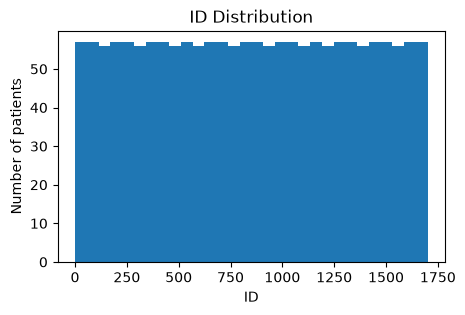

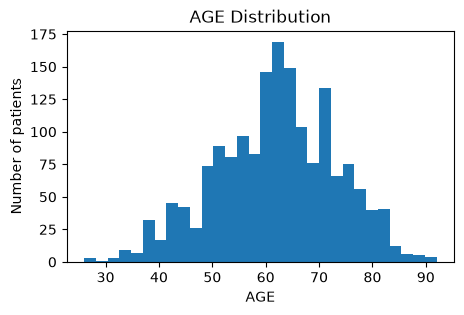

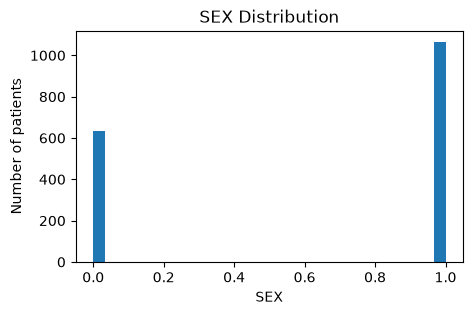

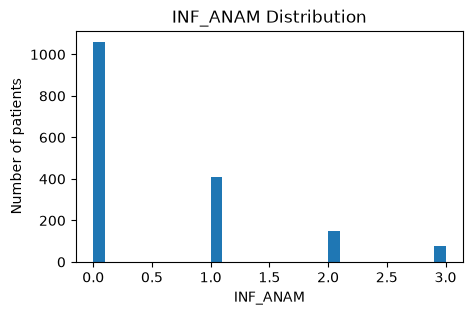

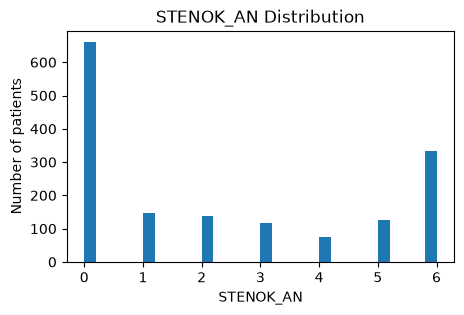

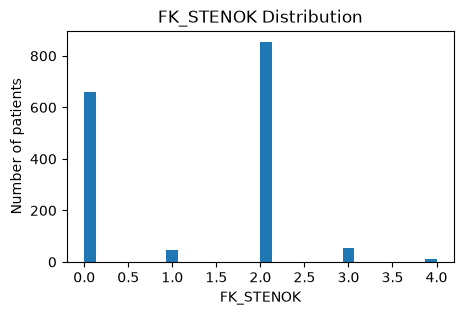

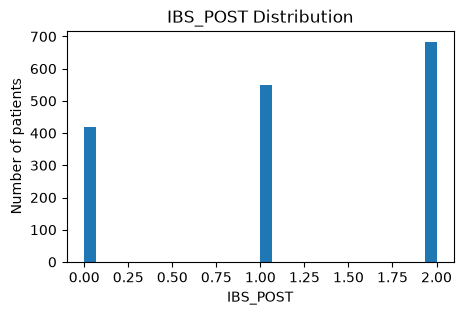

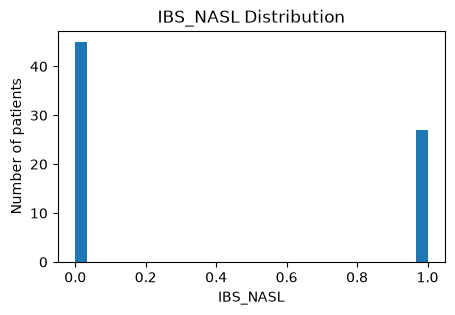

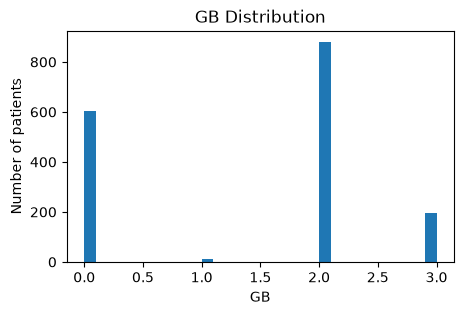

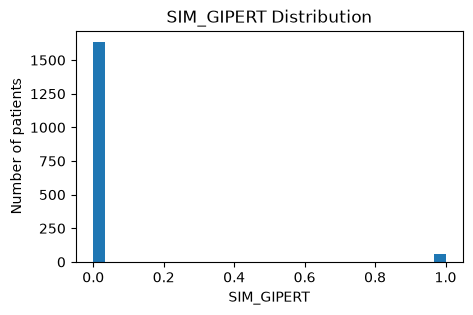

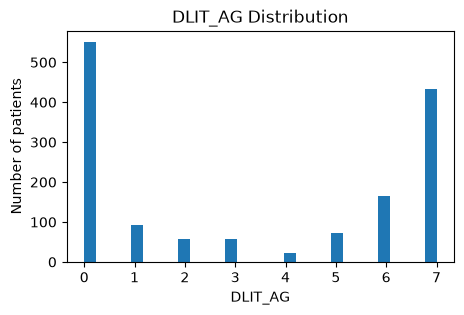

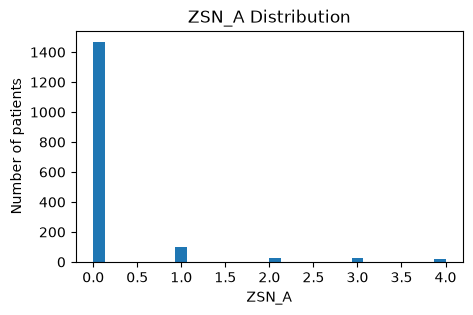

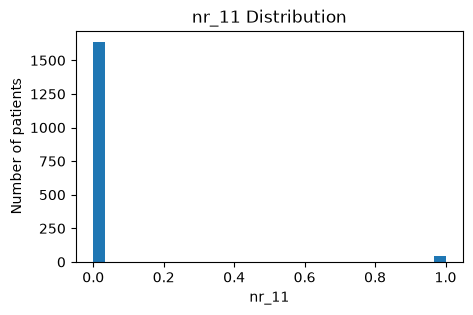

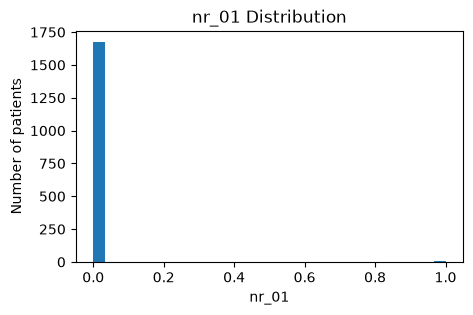

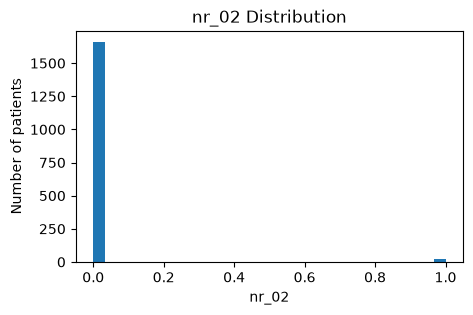

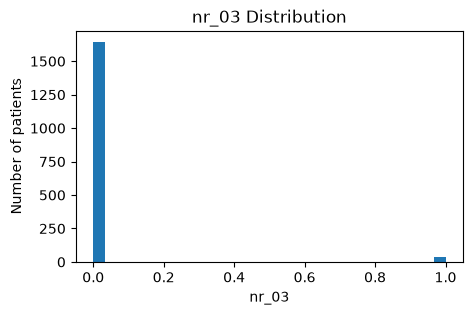

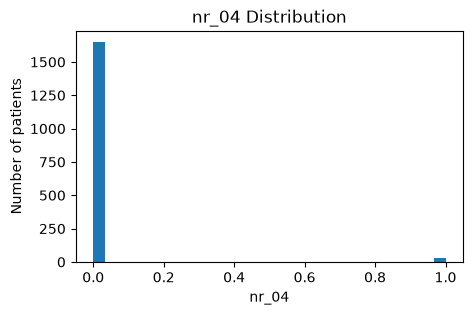

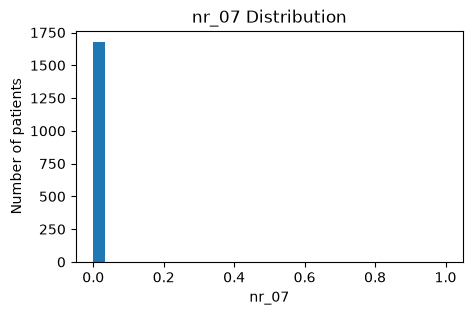

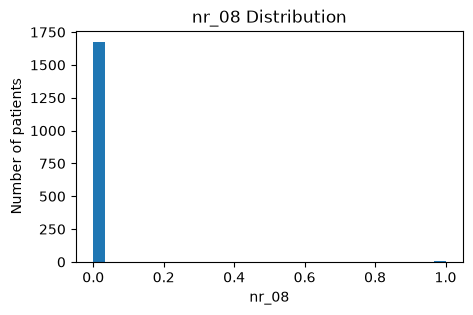

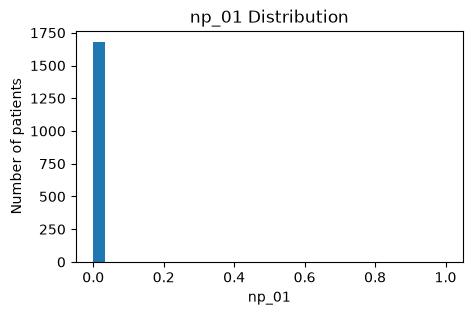

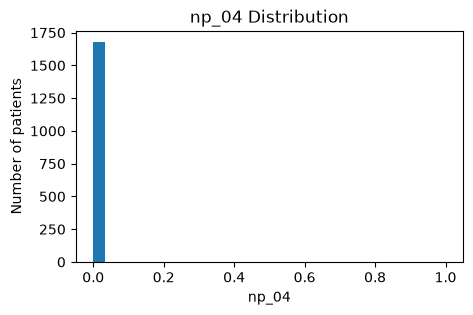

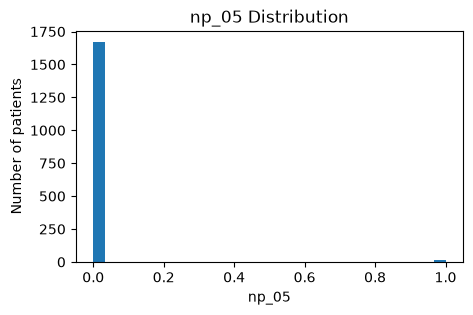

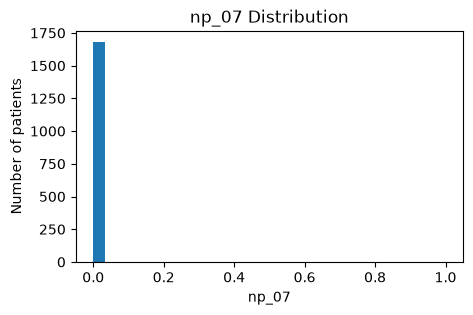

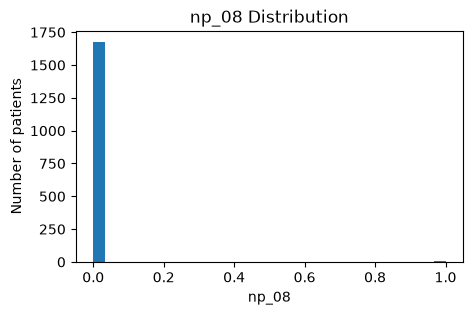

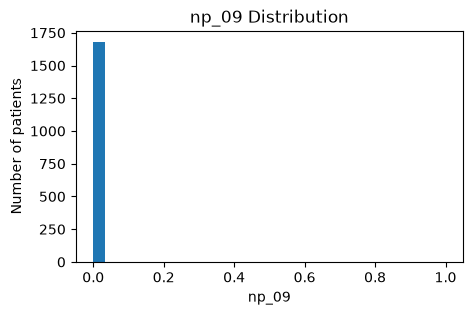

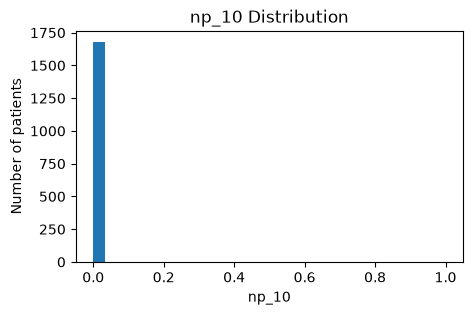

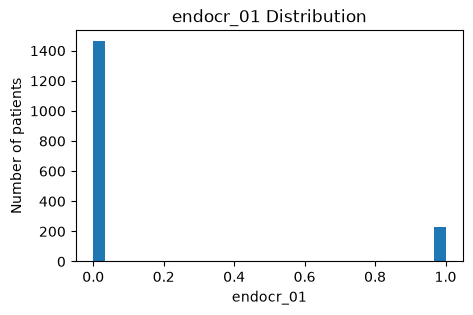

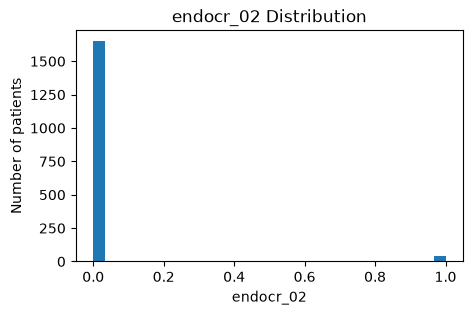

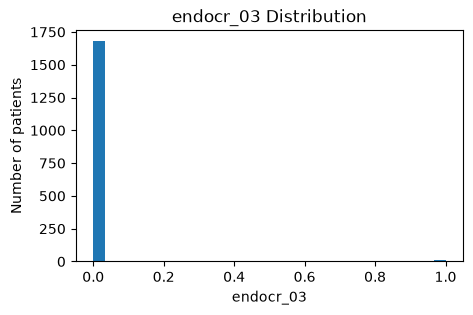

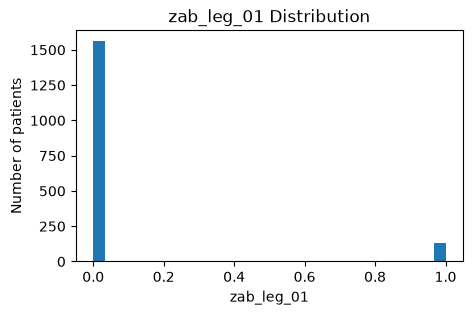

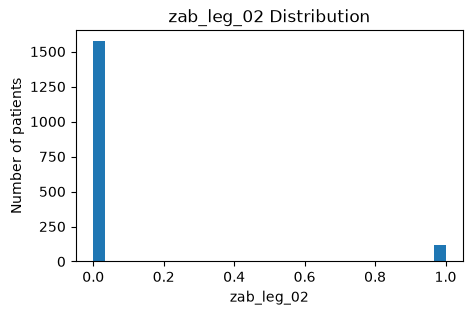

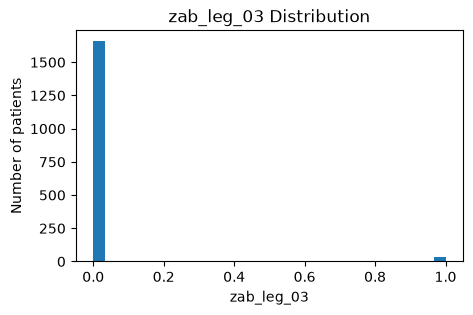

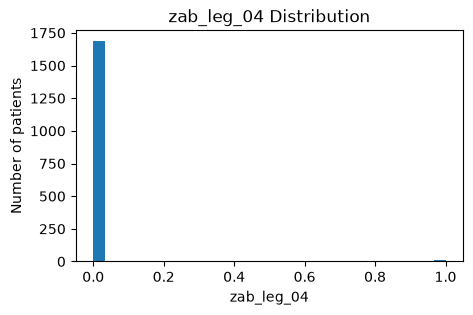

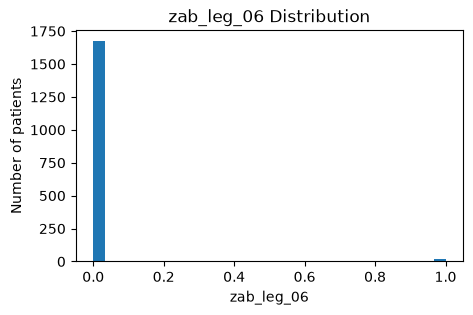

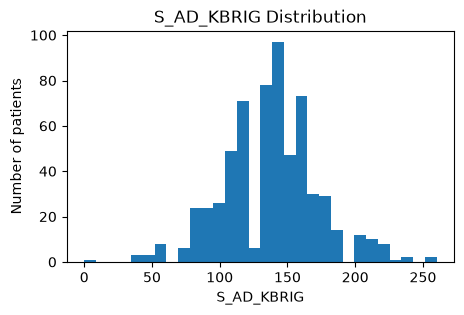

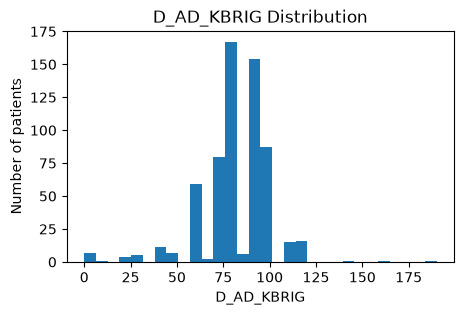

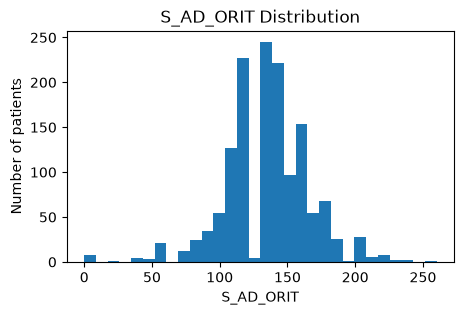

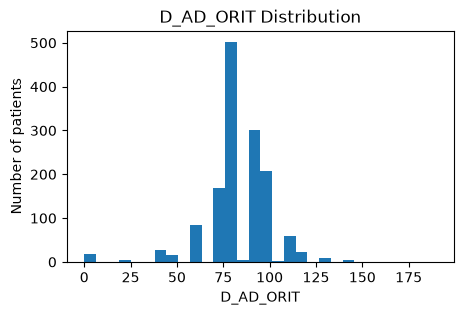

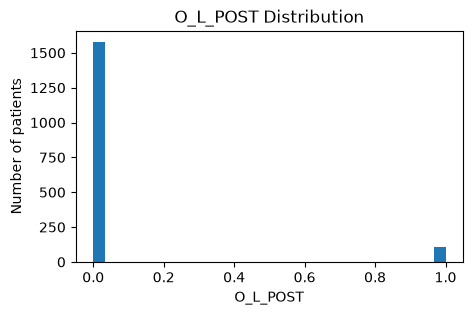

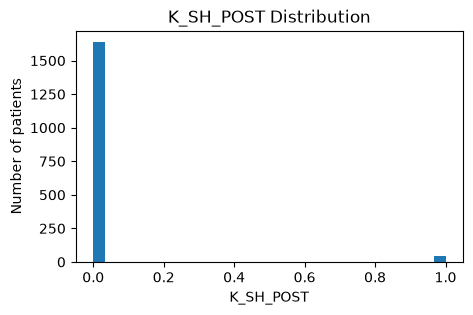

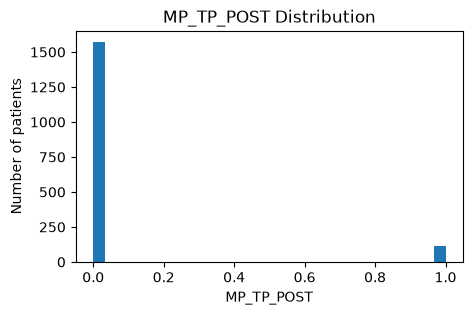

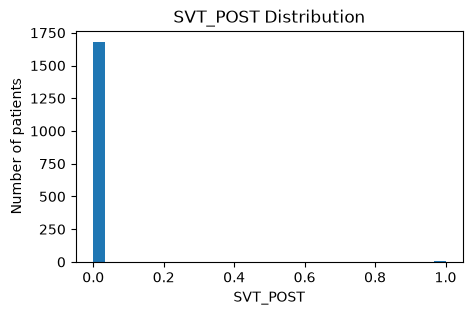

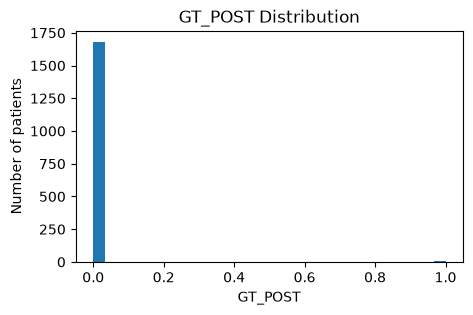

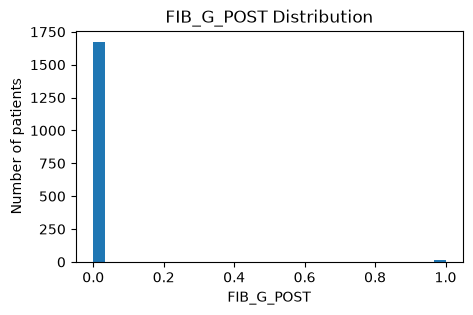

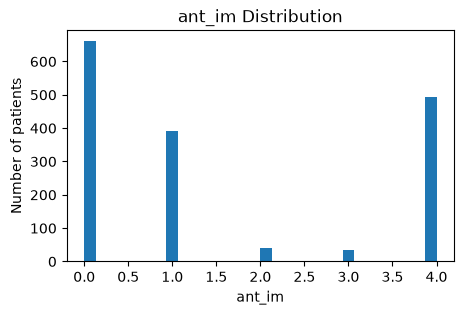

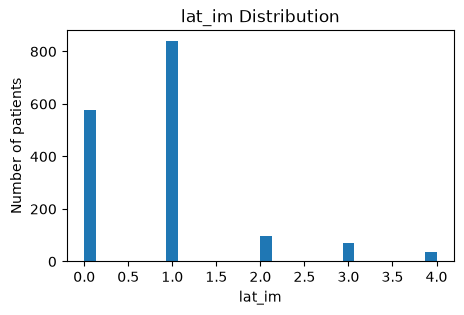

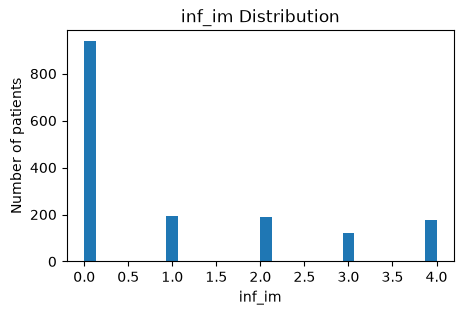

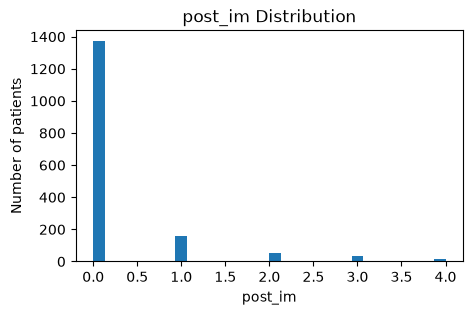

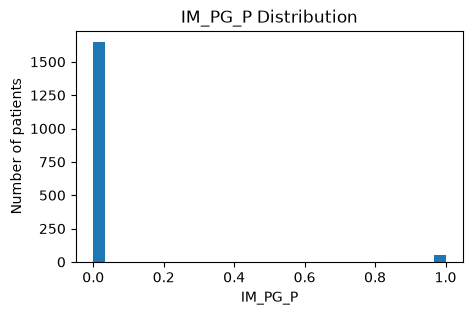

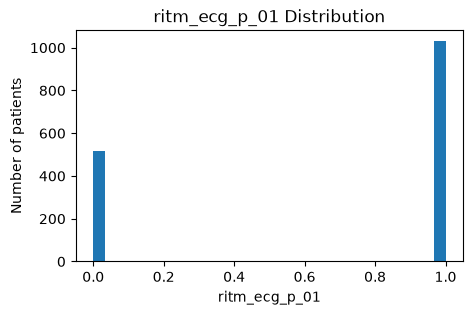

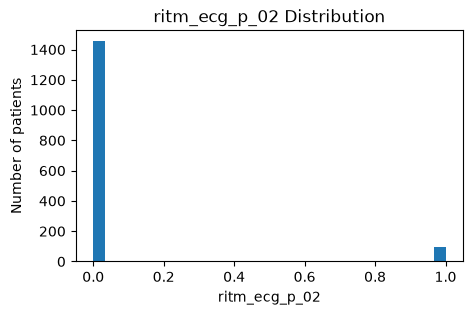

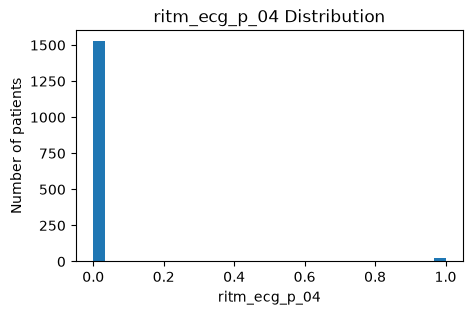

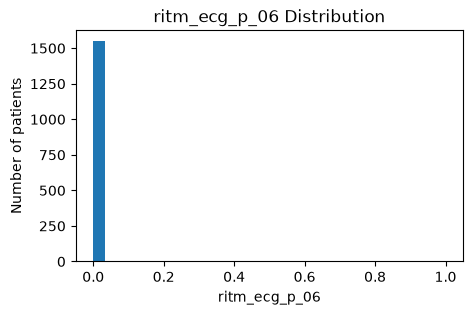

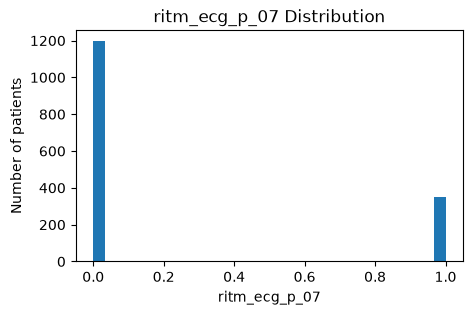

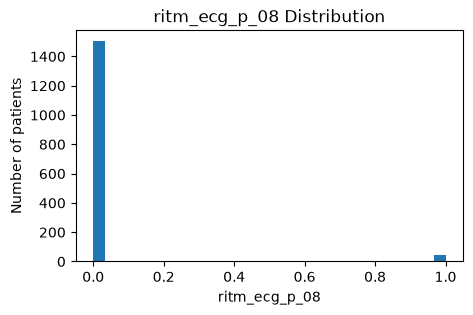

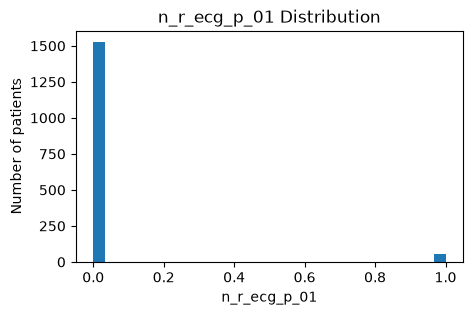

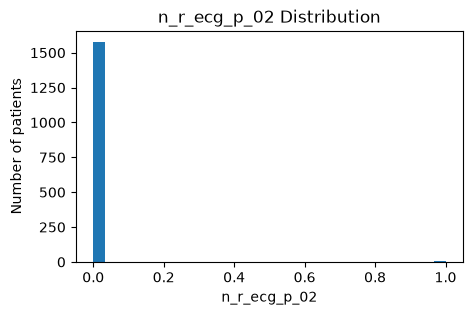

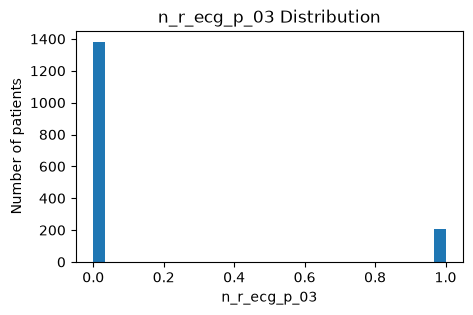

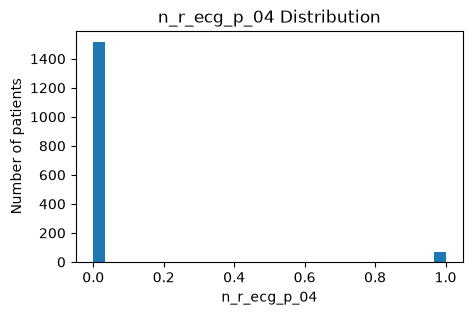

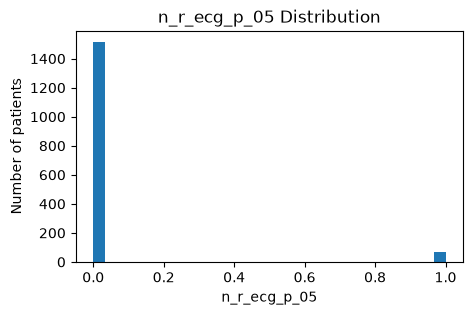

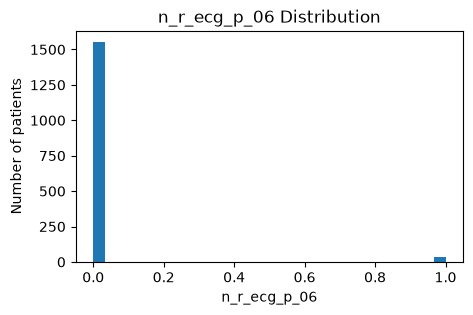

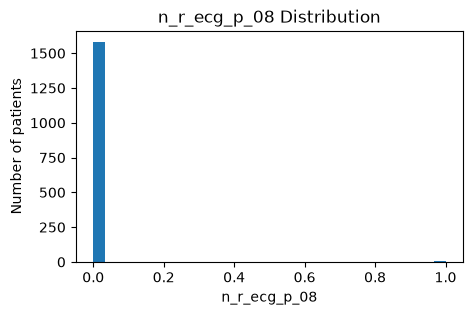

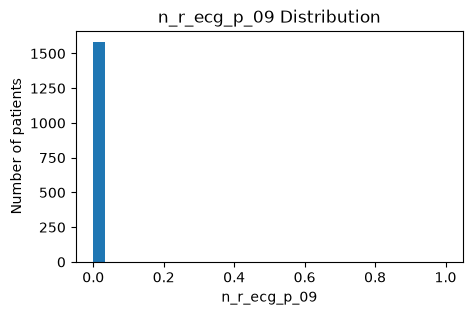

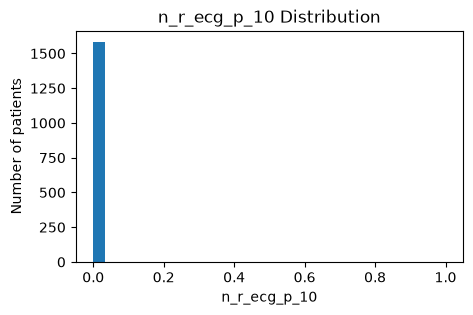

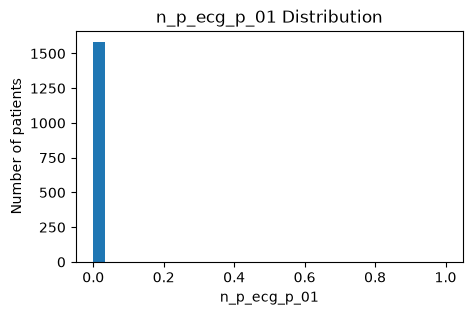

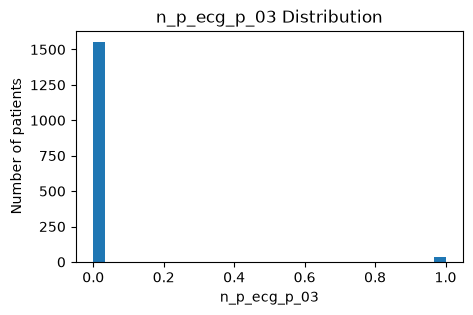

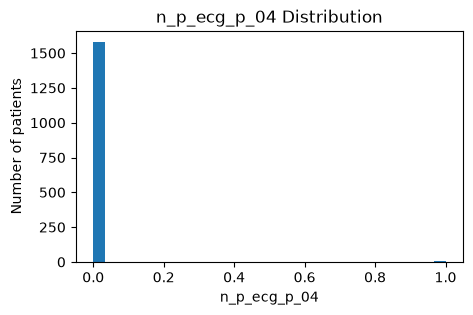

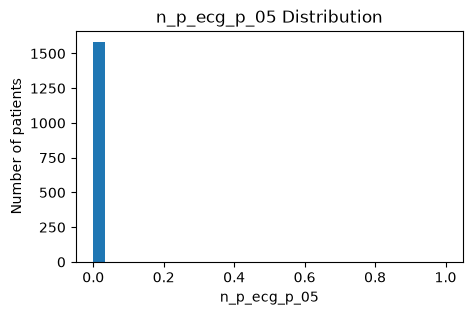

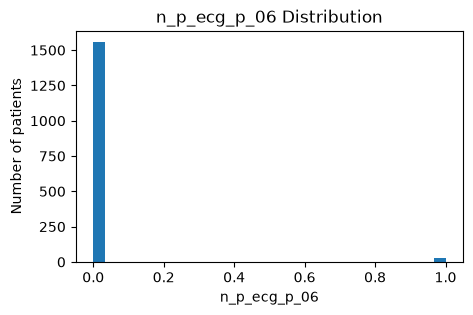

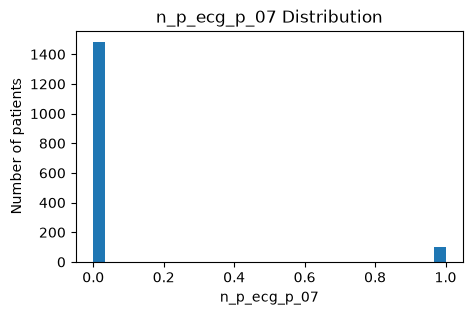

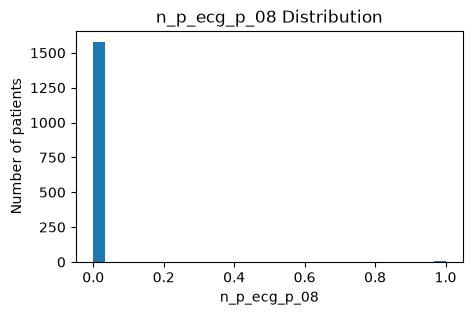

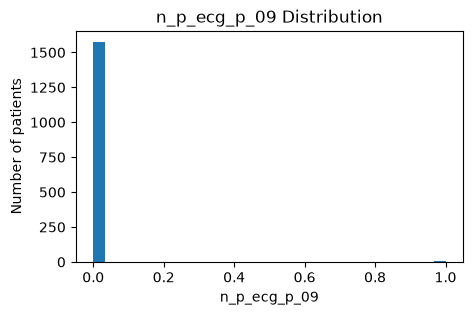

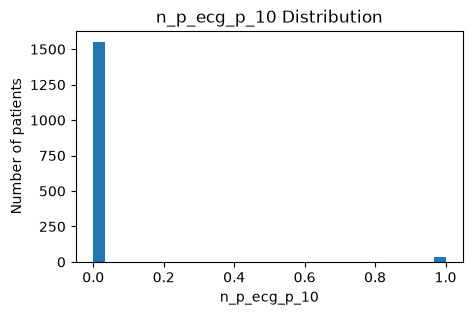

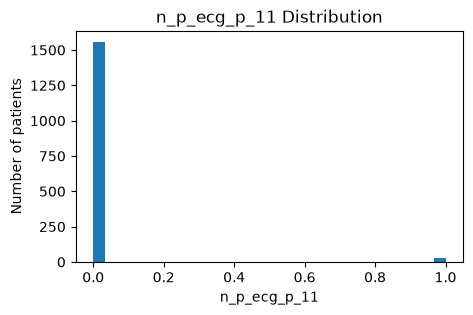

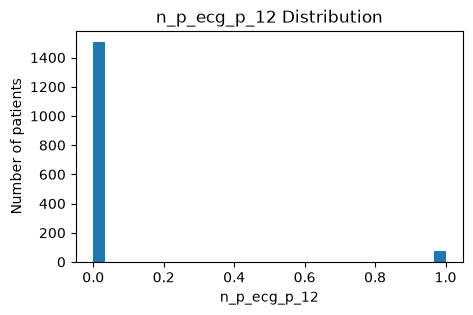

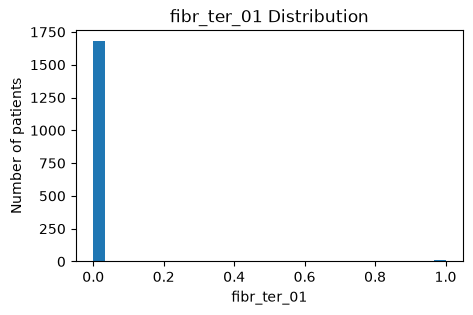

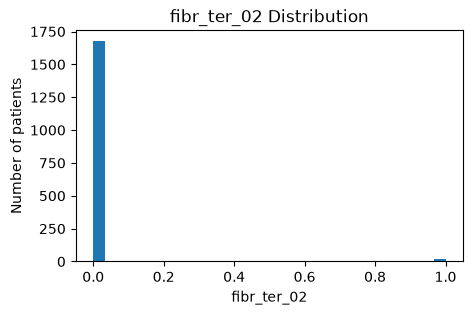

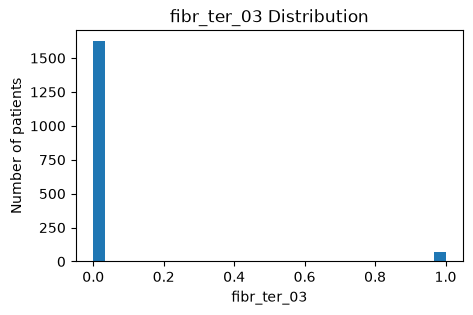

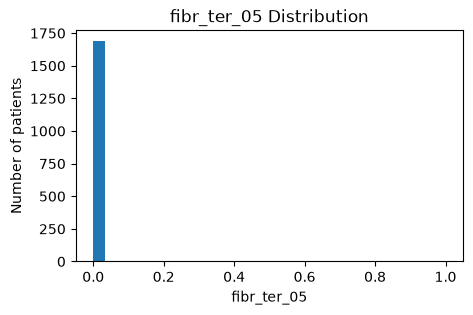

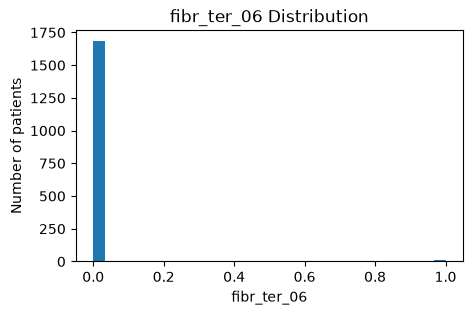

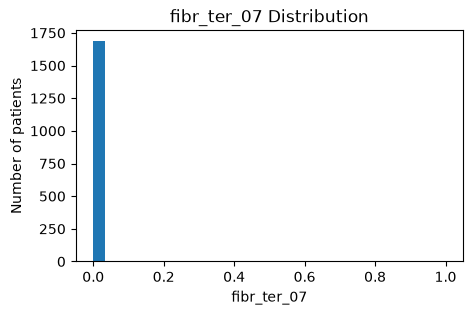

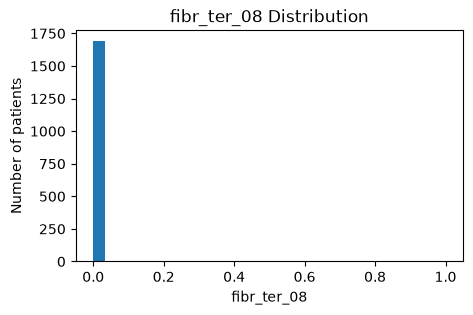

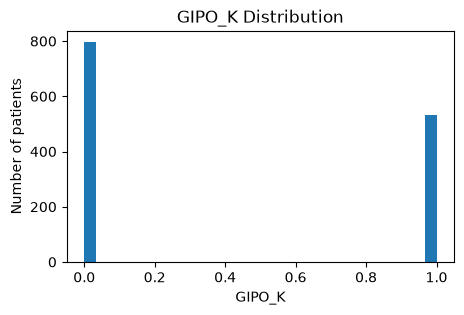

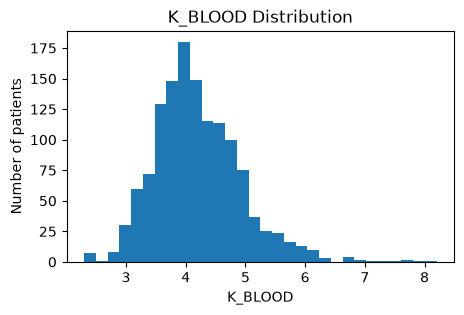

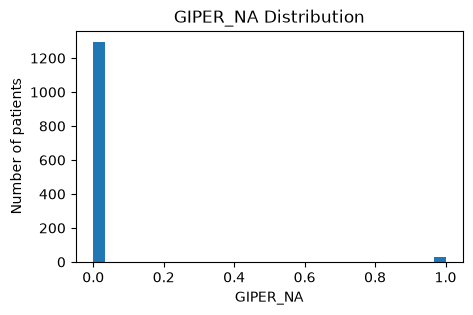

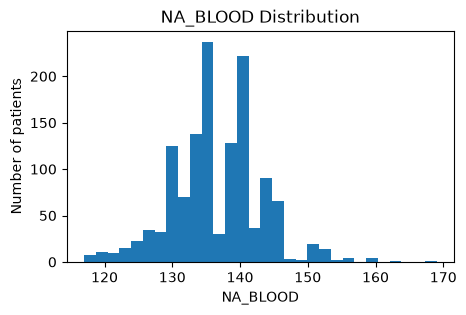

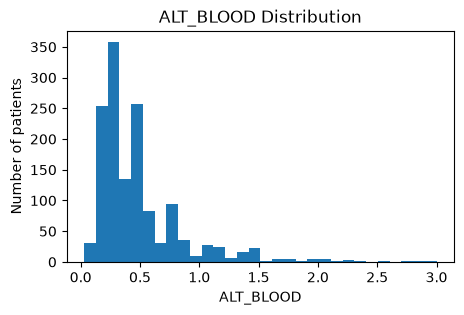

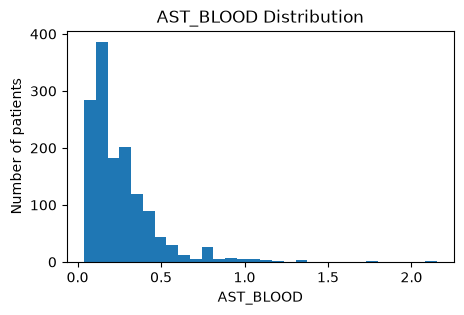

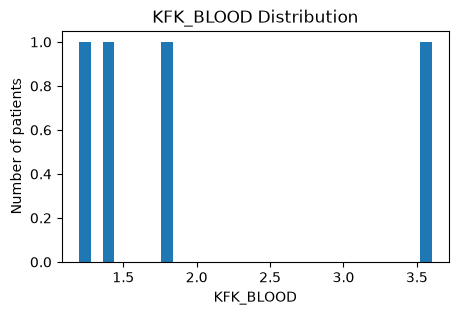

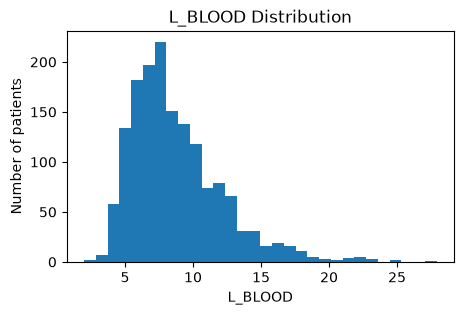

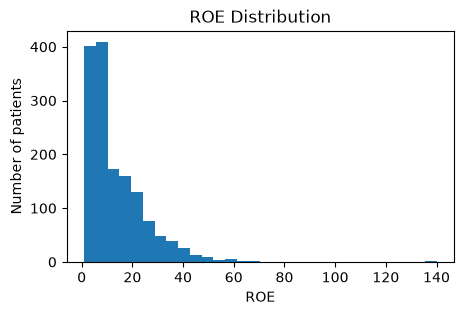

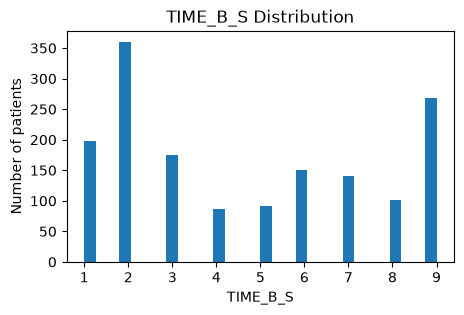

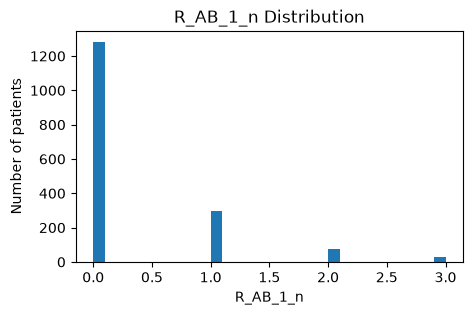

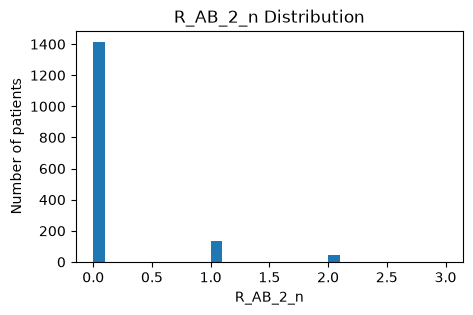

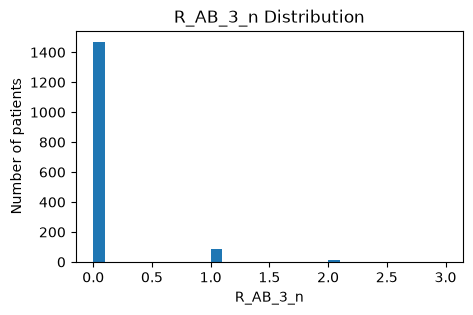

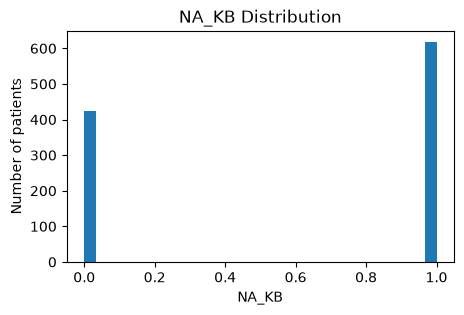

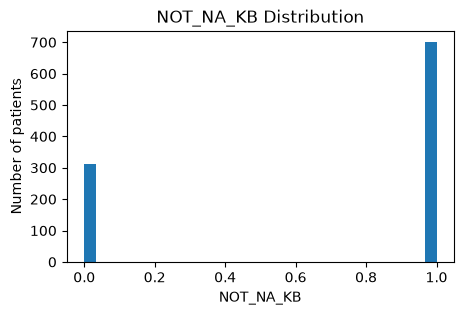

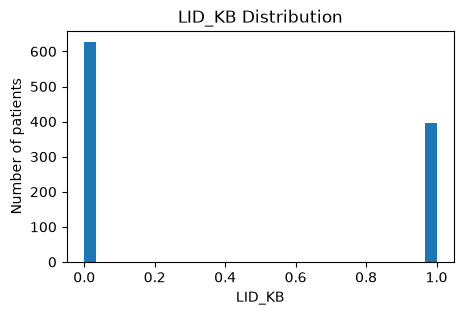

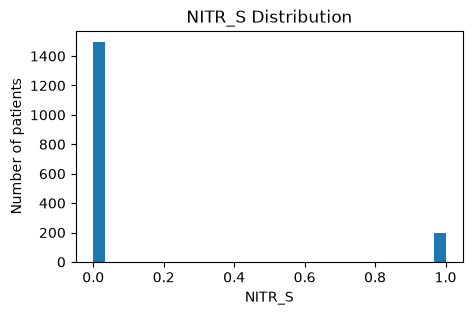

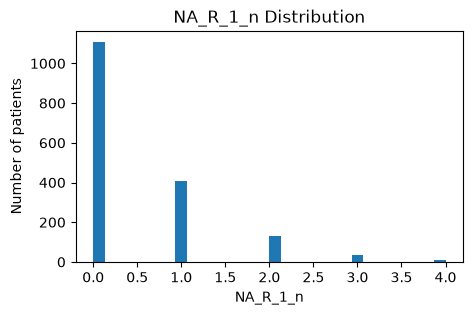

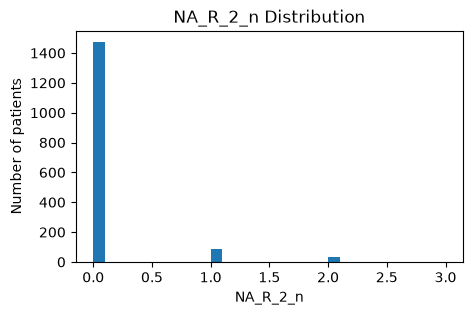

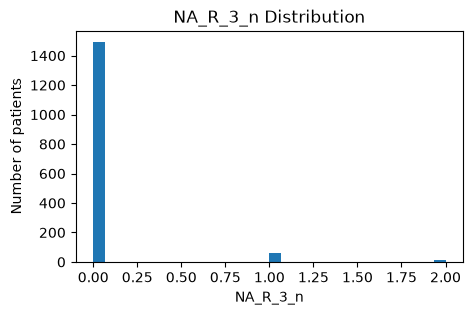

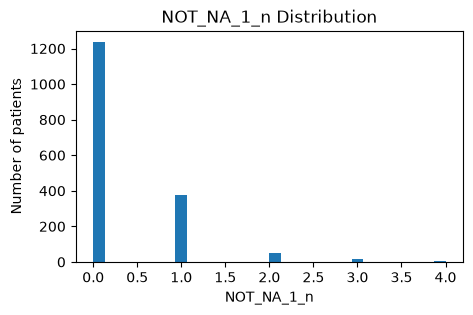

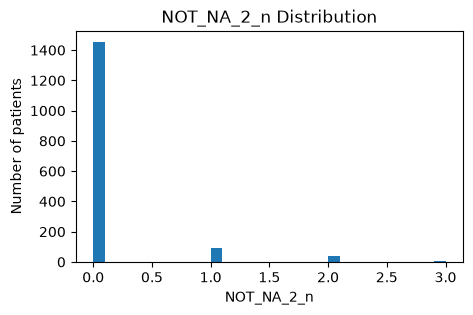

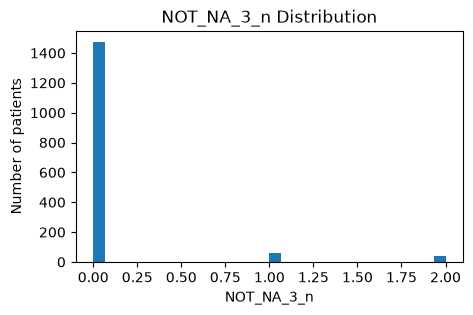

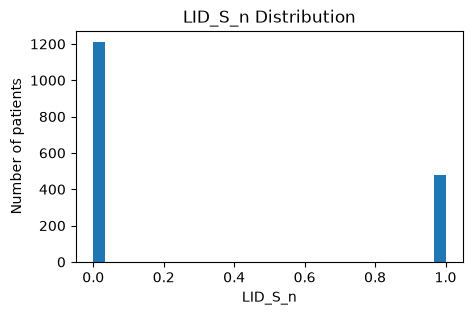

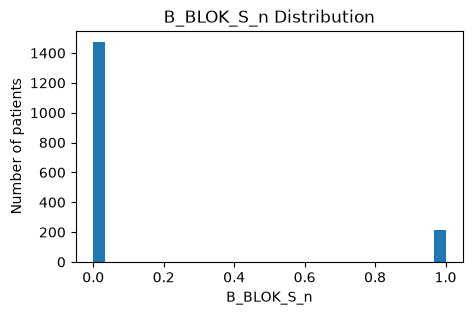

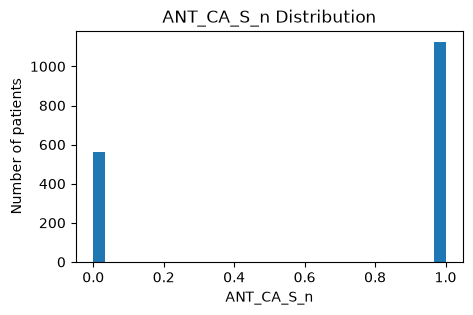

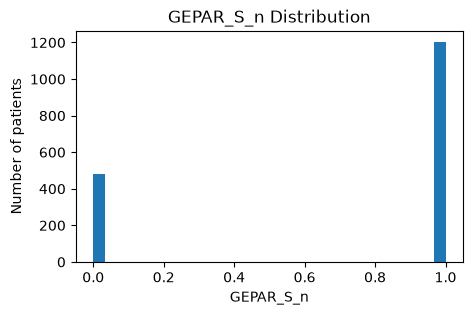

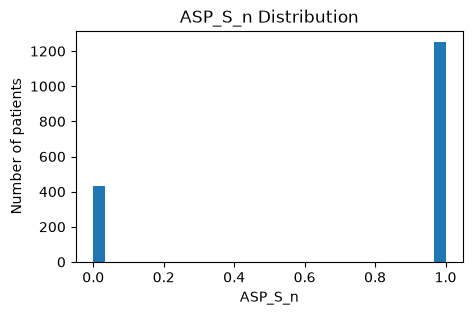

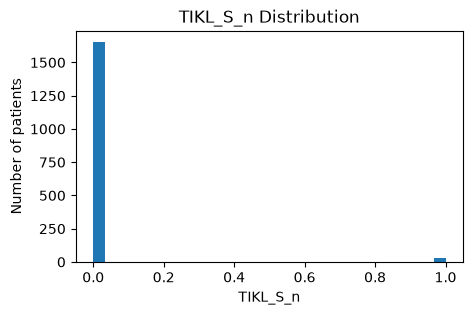

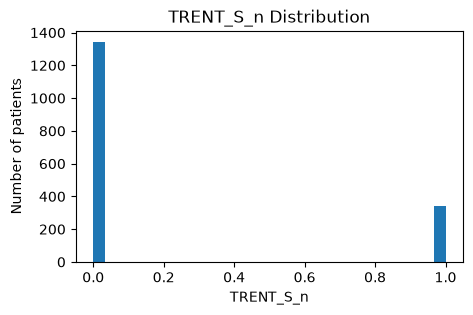

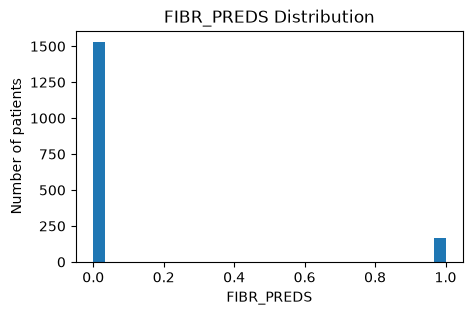

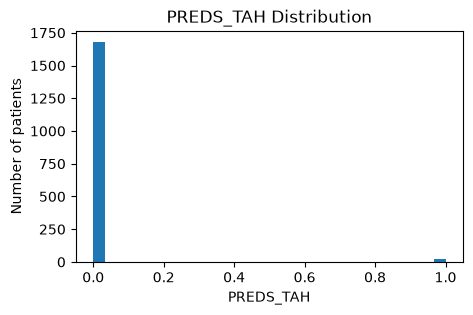

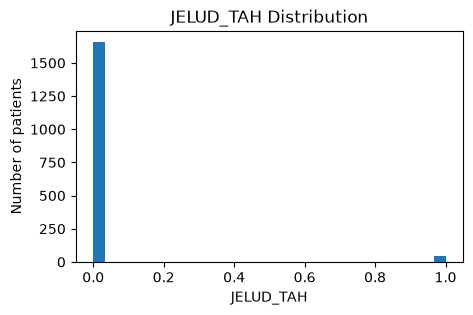

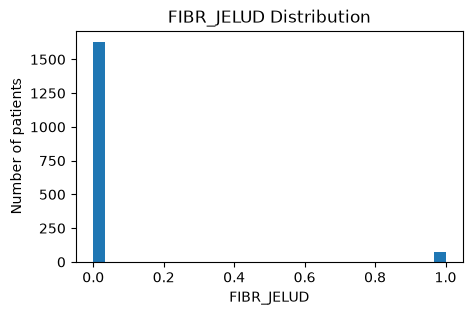

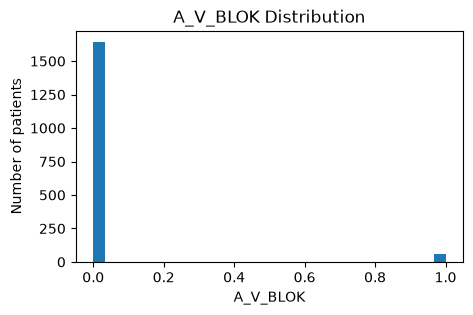

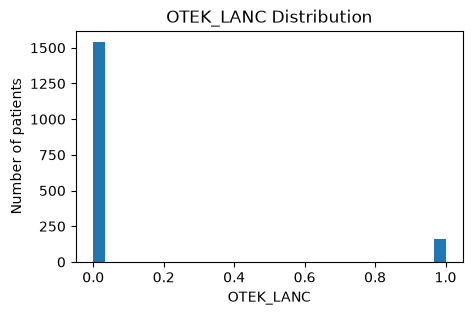

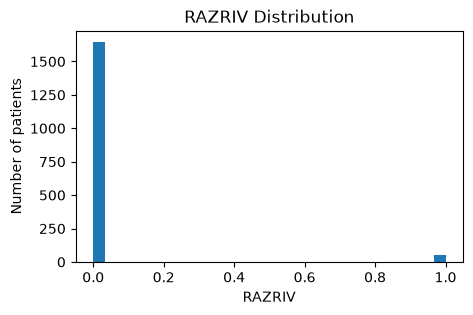

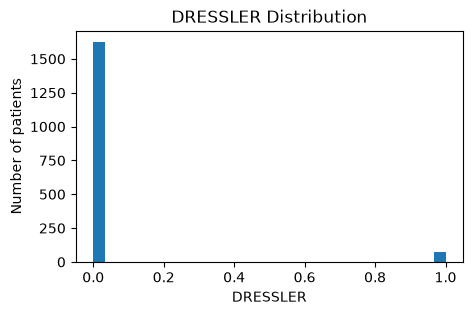

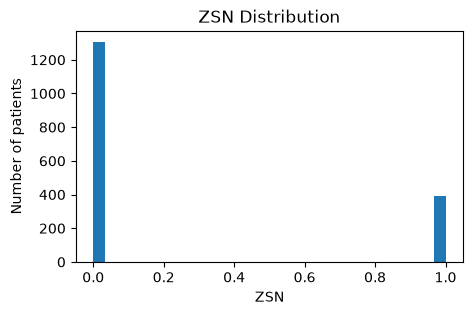

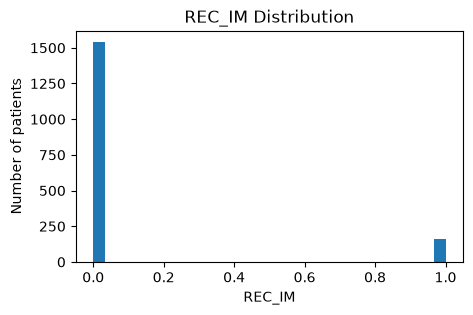

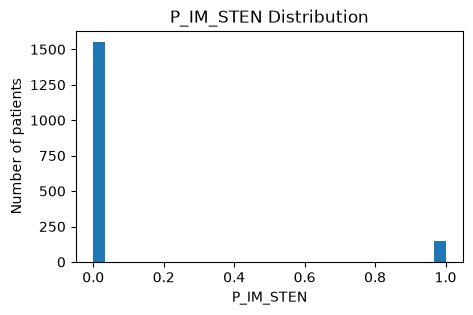

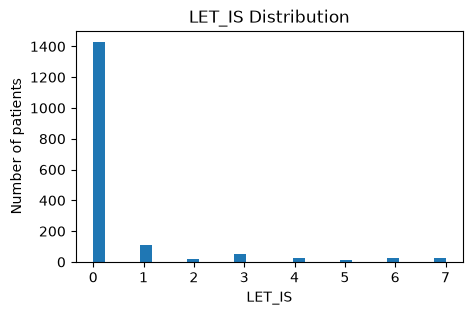

In [26]:
for col in numeric_columns:
    plt.figure(figsize=(5, 3))
    plt.hist(df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Number of patients")
    plt.title(f"{col} Distribution")
    plt.show()

In [27]:
for col in categorical_columns:
    print(f"\n===== {col} =====")
    display(df[col].value_counts(dropna=False).head(20))

In [28]:
binary_columns = []

for col in df.columns:
    values = df[col].dropna().unique()

    if len(values) <= 2 and set(values).issubset({0, 1}):
        binary_columns.append(col)

print("Binary columns:")
print(binary_columns)

Binary columns:
['SEX', 'IBS_NASL', 'SIM_GIPERT', 'nr_11', 'nr_01', 'nr_02', 'nr_03', 'nr_04', 'nr_07', 'nr_08', 'np_01', 'np_04', 'np_05', 'np_07', 'np_08', 'np_09', 'np_10', 'endocr_01', 'endocr_02', 'endocr_03', 'zab_leg_01', 'zab_leg_02', 'zab_leg_03', 'zab_leg_04', 'zab_leg_06', 'O_L_POST', 'K_SH_POST', 'MP_TP_POST', 'SVT_POST', 'GT_POST', 'FIB_G_POST', 'IM_PG_P', 'ritm_ecg_p_01', 'ritm_ecg_p_02', 'ritm_ecg_p_04', 'ritm_ecg_p_06', 'ritm_ecg_p_07', 'ritm_ecg_p_08', 'n_r_ecg_p_01', 'n_r_ecg_p_02', 'n_r_ecg_p_03', 'n_r_ecg_p_04', 'n_r_ecg_p_05', 'n_r_ecg_p_06', 'n_r_ecg_p_08', 'n_r_ecg_p_09', 'n_r_ecg_p_10', 'n_p_ecg_p_01', 'n_p_ecg_p_03', 'n_p_ecg_p_04', 'n_p_ecg_p_05', 'n_p_ecg_p_06', 'n_p_ecg_p_07', 'n_p_ecg_p_08', 'n_p_ecg_p_09', 'n_p_ecg_p_10', 'n_p_ecg_p_11', 'n_p_ecg_p_12', 'fibr_ter_01', 'fibr_ter_02', 'fibr_ter_03', 'fibr_ter_05', 'fibr_ter_06', 'fibr_ter_07', 'fibr_ter_08', 'GIPO_K', 'GIPER_NA', 'NA_KB', 'NOT_NA_KB', 'LID_KB', 'NITR_S', 'LID_S_n', 'B_BLOK_S_n', 'ANT_CA_S_n'

In [29]:
binary_summary = []

for col in binary_columns:
    positive = (df[col] == 1).sum()
    negative = (df[col] == 0).sum()
    total = positive + negative

    binary_summary.append({
        "target": col,
        "positive": positive,
        "negative": negative,
        "positive_percent": round(
            positive / total * 100, 2
        ) if total else np.nan
    })

binary_summary = pd.DataFrame(binary_summary)

display(
    binary_summary.sort_values(
        "positive_percent"
    )
)

,target,positive,negative,positive_percent
13,np_07,1,1681,0.06
8,nr_07,1,1678,0.06
35,ritm_ecg_p_06,1,1547,0.06
10,np_01,2,1680,0.12
15,np_09,2,1680,0.12
...,...,...,...,...
32,ritm_ecg_p_01,1029,519,66.47
73,ANT_CA_S_n,1125,562,66.69
68,NOT_NA_KB,701,313,69.13
74,GEPAR_S_n,1203,480,71.48


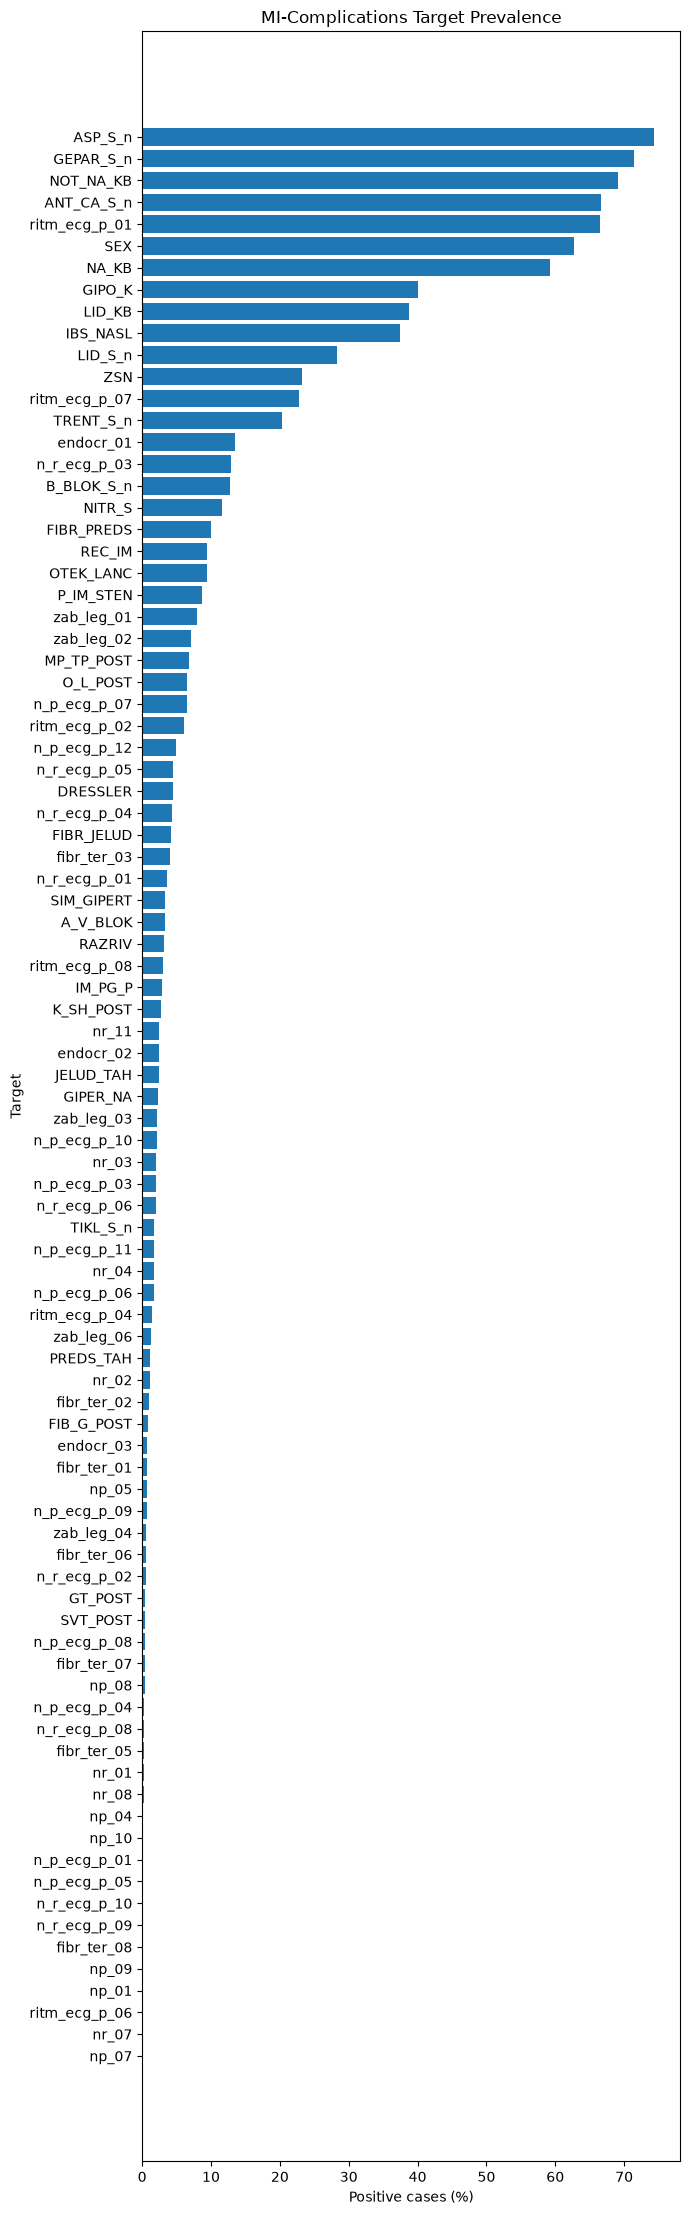

In [31]:
plot_df = binary_summary.sort_values(
    "positive_percent",
    ascending=True
)

plt.figure(figsize=(7, max(4, len(plot_df) * 0.25)))

plt.barh(
    plot_df["target"],
    plot_df["positive_percent"]
)

plt.xlabel("Positive cases (%)")
plt.ylabel("Target")
plt.title("MI-Complications Target Prevalence")

plt.tight_layout()
plt.show()

In [32]:
mortality_candidates = [
    col for col in df.columns
    if any(key in col.lower() for key in [
        "let_is",
        "death",
        "mort",
        "cause"
    ])
]

print("Possible mortality-related columns:")
print(mortality_candidates)

for col in mortality_candidates:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False))

Possible mortality-related columns:
['LET_IS']

LET_IS


LET_IS
0    1429
1     110
3      54
7      27
6      27
4      23
2      18
5      12
Name: count, dtype: int64

In [33]:
outlier_summary = []

for col in numeric_columns:
    values = df[col].dropna()

    if len(values) == 0:
        continue

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((values < lower) | (values > upper)).sum()

    outlier_summary.append({
        "feature": col,
        "outlier_count": int(count),
        "outlier_percent": round(
            count / len(values) * 100,
            2
        )
    })

outlier_df = pd.DataFrame(outlier_summary)

display(
    outlier_df.sort_values(
        "outlier_percent",
        ascending=False
    )
)

,feature,outlier_count,outlier_percent
92,R_AB_1_n,402,23.87
120,ZSN,394,23.18
53,ritm_ecg_p_07,353,22.80
111,TRENT_S_n,341,20.25
37,D_AD_ORIT,246,17.17
...,...,...,...
96,NOT_NA_KB,0,0.00
95,NA_KB,0,0.00
105,LID_S_n,0,0.00
109,ASP_S_n,0,0.00


In [35]:
summary = {
    "dataset": "MI Complications",
    "rows": len(df),
    "columns": len(df.columns),
    "duplicate_rows": int(df.duplicated().sum()),
    "numeric_columns": len(numeric_columns),
    "categorical_columns": len(categorical_columns),
    "binary_columns": len(binary_columns),
    "columns_ge_50pct_missing": len(high_missing),
}

summary_df = pd.DataFrame([summary])

display(summary_df)

,dataset,rows,columns,duplicate_rows,numeric_columns,categorical_columns,binary_columns,columns_ge_50pct_missing
0,MI Complications,1700,124,0,124,0,89,4


In [36]:
summary_df.to_csv(
    ARTIFACT_DIR / "mi_complications_eda_summary.csv",
    index=False
)

missing.to_csv(
    ARTIFACT_DIR / "missing_values.csv"
)

binary_summary.to_csv(
    ARTIFACT_DIR / "target_prevalence.csv",
    index=False
)

outlier_df.to_csv(
    ARTIFACT_DIR / "numeric_outliers.csv",
    index=False
)

print("EDA artifacts saved to:")
print(ARTIFACT_DIR)

EDA artifacts saved to:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\eda\mi_complications
